In [1]:
import sys
import os

print(sys.executable)
print(os.getcwd())

D:\Github_Ku\bda-recsys-project\Recsys\python.exe
D:\Github_Ku\bda-recsys-project\notebooks\external


***

This script performs:
1. Data preprocessing (cleaning + K-core filtering)
2. ID remapping
3. Sequence construction (for Transformer models)
4. Graph construction (User-Item + Item-Item)
5. Negative sampling (popularity-based)
6. PyTorch Dataset preparation
***

In [3]:
import pandas as pd
import torch
import random
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from tqdm import tqdm

In [5]:
# ==============================
# 1. Load Data
# ==============================

# Load dataset
df = pd.read_csv("D:/Github_Ku/bda-recsys-project/data/raw/ratings_Electronics.csv", header=None)
df.columns = ['userId', 'itemId', 'rating', 'timestamp']

print("Raw data size:", df.shape)

Raw data size: (1048576, 4)


In [6]:
# ==============================
# 2. Convert to Implicit Feedback
# ==============================

# Keep only positive interactions (rating >= 3)
df = df[df['rating'] >= 3]

print("After implicit filtering:", df.shape)
df.head()

After implicit filtering: (857681, 4)


,userId,itemId,rating,timestamp
0,AKM1MP6P0OYPR,132793040,5,1365811200
1,A2CX7LUOHB2NDG,321732944,5,1341100800
3,A2WNBOD3WNDNKT,439886341,3,1374451200
5,A1QGNMC6O1VW39,511189877,5,1397433600
7,A2TY0BTJOTENPG,511189877,5,1395878400


In [7]:
# ==============================
# 3. K-Core Filtering
# ==============================

def k_core_filter(df, k=5):
    """
    Iteratively remove users and items with interactions < k
    """
    while True:
        user_counts = df['userId'].value_counts()
        item_counts = df['itemId'].value_counts()

        df = df[
            df['userId'].isin(user_counts[user_counts >= k].index) &
            df['itemId'].isin(item_counts[item_counts >= k].index)
        ]

        # Stop condition
        if (user_counts < k).sum() == 0 and (item_counts < k).sum() == 0:
            break

    return df


df = k_core_filter(df, k=5)

print("After K-core filtering:", df.shape)
df.head()

After K-core filtering: (20402, 4)


,userId,itemId,rating,timestamp
389,A6J8D9V5S9MBE,972683275,5,1306886400
631,A3TAS1AG6FMBQW,972683275,5,1353456000
636,A2T4OX8NH9LIIC,972683275,5,1358553600
1003,A2Y4H3PXB07WQI,972683275,4,1292457600
1045,ABU4LUKJU2QOY,972683275,5,1378339200


In [8]:
# ==============================
# 4. ID Remapping
# ==============================

# user id can start from 0
user2id = {u: idx for idx, u in enumerate(df["userId"].unique())}

# item id must start from 1
# 0 is reserved for padding
item2id = {item: idx + 1 for idx, item in enumerate(df["itemId"].unique())}

df["userId"] = df["userId"].map(user2id)
df["itemId"] = df["itemId"].map(item2id)

num_users = len(user2id)
num_items = len(item2id)
padding_idx = 0

print("Number of users:", num_users)
print("Number of items:", num_items)
print("Padding idx:", padding_idx)
print("Min item id:", df["itemId"].min())
print("Max item id:", df["itemId"].max())

df.head()

Number of users: 2856
Number of items: 1706
Padding idx: 0
Min item id: 1
Max item id: 1706


,userId,itemId,rating,timestamp
389,0,1,5,1306886400
631,1,1,5,1353456000
636,2,1,5,1358553600
1003,3,1,4,1292457600
1045,4,1,5,1378339200


In [9]:
# ==============================
# 5. Sort by Time (Sequence Modeling)
# ==============================

df = df.sort_values(['userId', 'timestamp'])

# Build user sequences
user_seq = df.groupby('userId')['itemId'].apply(list)

print("Example user sequence:", user_seq.iloc[0])

Example user sequence: [230, 1671, 1038, 220, 1101, 1436, 472, 1250, 1441, 1, 1670]


In [10]:
# ==============================
# 6. Build Graphs (FULL DATA)
# ==============================

# ---- User-Item Graph ----
user_nodes = df['userId'].values
item_nodes = df['itemId'].values + num_users

edge_index_ui = torch.tensor([
    list(user_nodes) + list(item_nodes),
    list(item_nodes) + list(user_nodes)
], dtype=torch.long)


# ---- Item-Item Graph ----
def build_item_graph(user_seq, window=3):
    cooc = defaultdict(int)

    for seq in tqdm(user_seq):
        for i in range(len(seq)):
            for j in range(i+1, min(i+window, len(seq))):
                cooc[(seq[i], seq[j])] += 1
                cooc[(seq[j], seq[i])] += 1

    edges = list(cooc.keys())
    return torch.tensor(edges, dtype=torch.long).t()


edge_index_ii = build_item_graph(user_seq)

print("User-Item graph edges:", edge_index_ui.shape)
print("Item-Item graph edges:", edge_index_ii.shape)



100%|██████████| 2856/2856 [00:00<00:00, 31260.10it/s]

User-Item graph edges: torch.Size([2, 40804])
Item-Item graph edges: torch.Size([2, 56952])


In [11]:
# ==============================
# 7. Time-based Split
# ==============================

train_data, val_data, test_data = [], [], []

for u, seq in user_seq.items():
    if len(seq) < 3:
        continue

    train_seq = seq[:-2]
    val_item = seq[-2]
    test_item = seq[-1]

    train_data.append((u, train_seq))
    val_data.append((u, train_seq, val_item))
    test_data.append((u, train_seq + [val_item], test_item))


print("Train samples:", len(train_data))
print("Val samples:", len(val_data))
print("Test samples:", len(test_data))


Train samples: 2856
Val samples: 2856
Test samples: 2856


In [12]:
import os
import torch

export_dir = r"D:\Github_Ku\bda-recsys-project\data\interim"
os.makedirs(export_dir, exist_ok=True)

print("Export dir:", export_dir)
print("Exists:", os.path.exists(export_dir))

Export dir: D:\Github_Ku\bda-recsys-project\data\interim
Exists: True


In [13]:
clean_user_sequences = {}

df_sorted = df.sort_values(["userId", "timestamp"]).copy()

for user_id, user_df in df_sorted.groupby("userId"):
    clean_user_sequences[int(user_id)] = {
        "items": user_df["itemId"].tolist(),
        "times": user_df["timestamp"].tolist(),
    }

print("number of users in clean_user_sequences:", len(clean_user_sequences))

first_user = next(iter(clean_user_sequences))
print("first user:", first_user)
print(clean_user_sequences[first_user])

torch.save(clean_user_sequences, os.path.join(export_dir, "clean_user_sequences.pt"))
print("Saved clean_user_sequences.pt")

number of users in clean_user_sequences: 2856
first user: 0
{'items': [230, 1671, 1038, 220, 1101, 1436, 472, 1250, 1441, 1, 1670], 'times': [1162252800, 1171756800, 1192147200, 1192752000, 1201392000, 1223251200, 1232236800, 1232236800, 1232236800, 1306886400, 1308096000]}
Saved clean_user_sequences.pt


In [14]:
artifacts = {
    "train_data": train_data,
    "val_data": val_data,
    "test_data": test_data,
    "user2id": user2id,
    "item2id": item2id,
    "num_users": num_users,
    "num_items": num_items,
    "padding_idx": 0,
}

torch.save(artifacts, os.path.join(export_dir, "sequence_artifacts.pt"))
print("Saved sequence_artifacts.pt")

Saved sequence_artifacts.pt


In [15]:
torch.save(edge_index_ui, os.path.join(export_dir, "edge_index_ui.pt"))
torch.save(edge_index_ii, os.path.join(export_dir, "edge_index_ii.pt"))

print("Saved edge_index_ui.pt")
print("Saved edge_index_ii.pt")

Saved edge_index_ui.pt
Saved edge_index_ii.pt


In [13]:
# ==============================
# 8. Popularity-based Negative Sampling
# ==============================

train_items = []

for _, seq in train_data:
    train_items.extend(seq)

item_popularity = pd.Series(train_items).value_counts().to_dict()

items = list(item_popularity.keys())
weights = [item_popularity[i] for i in items]

def negative_sample(user_history, num_samples=100):
    """
    Popularity-based negative sampling
    Avoid sampling items already interacted by user
    """
    negs = set()

    while len(negs) < num_samples:
        sampled = random.choices(items, weights=weights, k=1)[0]

        if sampled not in user_history:
            negs.add(sampled)

    return list(negs)

In [14]:
# ==============================
# 9. Dataset (Transformer-ready)
# ==============================

class TrainDataset(torch.utils.data.Dataset):
    def __init__(self, data, max_len=50, neg_size=1):
        self.data = data
        self.max_len = max_len
        self.neg_size = neg_size

    def pad(self, seq):
        seq = seq[-self.max_len:]
        return [0]*(self.max_len - len(seq)) + seq

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        u, seq = self.data[idx]

        input_seq = self.pad(seq[:-1])
        pos_item = seq[-1]

        # negative sampling
        neg_items = negative_sample(seq, self.neg_size)

        return (
            torch.tensor(input_seq),
            torch.tensor(pos_item),
            torch.tensor(neg_items)
        )
    
class EvalTestDataset(torch.utils.data.Dataset):
    def __init__(self, data, max_len=50):
        self.data = data
        self.max_len = max_len

    def pad(self, seq):
        seq = seq[-self.max_len:]
        return [0]*(self.max_len - len(seq)) + seq

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        u, seq, target = self.data[idx]

        input_seq = self.pad(seq)

        return torch.tensor(input_seq), torch.tensor(target)
    
train_dataset = TrainDataset(train_data)
val_dataset = EvalTestDataset(val_data)
test_dataset = EvalTestDataset(test_data)

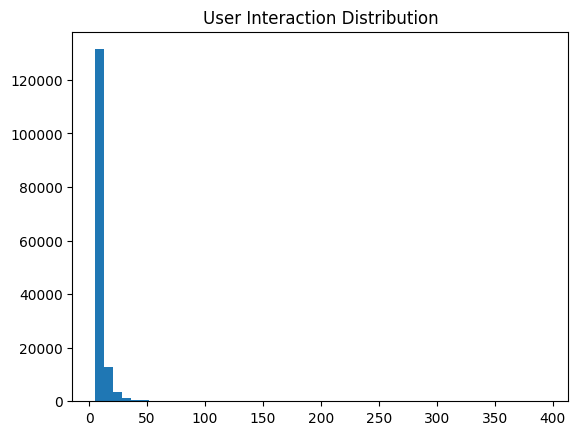

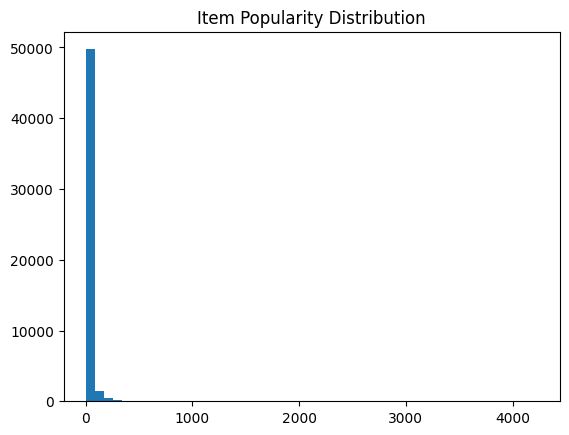

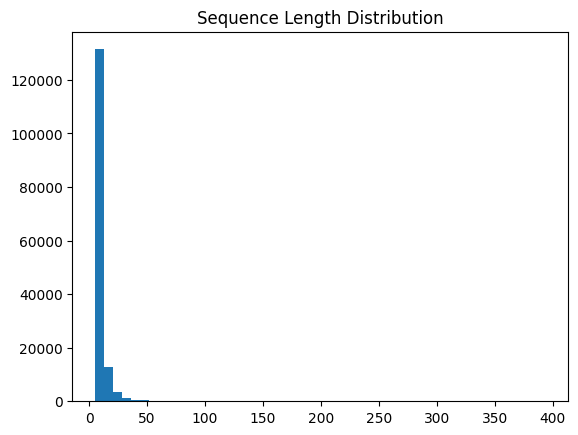

In [15]:
    # ==============================
    # 10. Data Visualization
    # ==============================

    # User distribution
    plt.figure()
    plt.hist(df['userId'].value_counts(), bins=50)
    plt.title("User Interaction Distribution")
    plt.show()

    # Item distribution
    plt.figure()
    plt.hist(df['itemId'].value_counts(), bins=50)
    plt.title("Item Popularity Distribution")
    plt.show()

    # Sequence length
    plt.figure()
    plt.hist(user_seq.apply(len), bins=50)
    plt.title("Sequence Length Distribution")
    plt.show()


In [16]:
# ==============================
# 11. Sparsity
# ==============================

sparsity = 1 - len(df)/(num_users*num_items)
print("Sparsity:", sparsity)

Sparsity: 0.999832399955512


In [17]:
# ==============================
# 12. Save
# ==============================

torch.save(edge_index_ui, "edge_index_ui.pt")
torch.save(edge_index_ii, "edge_index_ii.pt")

In [18]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GraphTransformerRec(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, num_heads=4, num_layers=2, max_len=50):
        super(GraphTransformerRec, self).__init__()
        
        self.embedding_dim = embedding_dim
        
        # 1. Embeddings
        # 物品ID从0开始，0通常留给Padding，所以这里num_items+1
        self.item_emb = nn.Embedding(num_items + 1, embedding_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, embedding_dim)
        
        # 2. Graph Branch (GCN) - 学习全局物品表示
        self.gcn1 = GCNConv(embedding_dim, embedding_dim)
        self.gcn2 = GCNConv(embedding_dim, embedding_dim)
        
        # 3. Sequence Branch (Transformer) - 学习用户行为模式
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim, 
            nhead=num_heads, 
            dim_feedforward=embedding_dim*4,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.dropout = nn.Dropout(0.1)

    def forward(self, seq, edge_index_ii):
        # A. 图特征提取
        # 获取所有物品的初始embedding
        all_item_ids = torch.arange(self.item_emb.num_embeddings).to(seq.device)
        x = self.item_emb(all_item_ids)
        
        # 两层GCN：增强物品的结构信息
        x_g = F.relu(self.gcn1(x, edge_index_ii))
        x_g = self.gcn2(x_g, edge_index_ii) 
        
        # B. 序列特征提取
        # 获取序列中物品经过GCN增强后的embedding
        seq_emb = x_g[seq] # [batch, max_len, dim]
        
        # 加上位置编码
        batch_size, seq_len = seq.size()
        pos = torch.arange(seq_len).unsqueeze(0).to(seq.device)
        pos_emb = self.pos_emb(pos)
        
        seq_features = self.dropout(seq_emb + pos_emb)
        
        # Transformer 处理 (需要考虑Padding mask)
        mask = (seq == 0) # 假设0是padding
        out = self.transformer(seq_features, src_key_padding_mask=mask)
        
        # 取最后一个时间步作为用户表示
        user_repr = out[:, -1, :] 
        
        return user_repr, x_g # 返回用户表示和全局物品表示

C:\Users\Ryan\miniconda3\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
def bpr_loss(user_emb, pos_item_emb, neg_item_emb):
    pos_score = torch.sum(user_emb * pos_item_emb, dim=-1)
    neg_score = torch.sum(user_emb * neg_item_emb, dim=-1)
    loss = -torch.mean(F.logsigmoid(pos_score - neg_score))
    return loss

def train_one_epoch(model, loader, optimizer, edge_index, device):
    model.train()
    total_loss = 0
    for seq, pos_item, neg_item in loader:
        seq, pos_item, neg_item = seq.to(device), pos_item.to(device), neg_item.to(device)
        
        optimizer.zero_grad()
        user_repr, item_embs = model(seq, edge_index)
        
        # 提取正负样本的 embedding
        pos_emb = item_embs[pos_item]
        neg_emb = item_embs[neg_item].squeeze(1) # [batch, dim]
        
        loss = bpr_loss(user_repr, pos_emb, neg_emb)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

In [20]:
@torch.no_grad()
def evaluate(model, loader, edge_index, device, k=10):
    model.eval()
    hr, ndcg = [], []
    
    # 预先计算所有物品的表示以加速
    _, all_item_embs = model(torch.zeros((1, 50), dtype=torch.long).to(device), edge_index)
    
    for seq, target in loader:
        seq, target = seq.to(device), target.to(device)
        user_repr, _ = model(seq, edge_index)
        
        # 计算该用户对所有物品的得分
        scores = torch.matmul(user_repr, all_item_embs.t()) # [batch, num_items]
        
        # 获取 Top-K
        _, top_k_idx = torch.topk(scores, k, dim=-1)
        
        for i in range(len(target)):
            gt = target[i].item()
            recs = top_k_idx[i].cpu().numpy()
            
            # Hit Rate
            if gt in recs:
                hr.append(1)
                # NDCG
                rank = list(recs).index(gt)
                ndcg.append(1 / np.log2(rank + 2))
            else:
                hr.append(0)
                ndcg.append(0)
                
    return np.mean(hr), np.mean(ndcg)

Using device: cuda


  Training:   5%|██▋                                               | 32/588 [00:25<07:16,  1.27it/s, batch_loss=0.6807]


  Training:  11%|█████▌                                            | 65/588 [00:51<06:54,  1.26it/s, batch_loss=0.6793]


  Training:  17%|████████▎                                         | 98/588 [01:17<06:22,  1.28it/s, batch_loss=0.6759]


  Training:  22%|██████████▉                                      | 131/588 [01:42<05:55,  1.28it/s, batch_loss=0.6773]


...

  Evaluating:  69%|█████████████████████████████████████████████▎                    | 404/588 [00:53<00:22,  8.32it/s]


  Evaluating:  80%|████████████████████████████████████████████████████▊             | 470/588 [01:01<00:14,  7.91it/s]


  Evaluating:  91%|████████████████████████████████████████████████████████████▏     | 536/588 [01:09<00:06,  8.43it/s]


Total Progress: 100%|███████████████████████████████████████████████████████████████████| 1/1 [09:01<00:00, 541.71s/it]


Epoch 01 | Loss: 0.6310 | HR@10: 0.0123 | NDCG@10: 0.0062


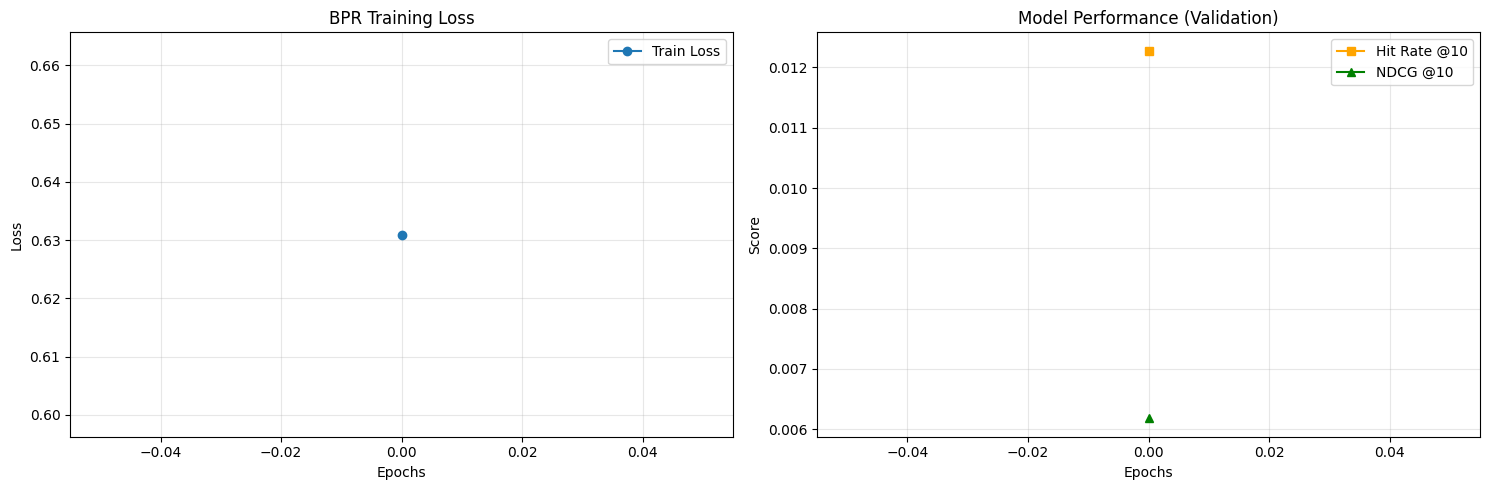

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 12. 模型定义 (包含 Robust Mask 修复)
# ==============================
class GraphTransformerRec(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, num_heads=4, num_layers=2, max_len=50):
        super(GraphTransformerRec, self).__init__()
        
        self.embedding_dim = embedding_dim
        # 物品ID映射，0用于Padding，实际物品从1开始（或映射后偏移）
        self.item_emb = nn.Embedding(num_items + 1, embedding_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, embedding_dim)
        
        # GCN 部分
        self.gcn1 = GCNConv(embedding_dim, embedding_dim)
        self.gcn2 = GCNConv(embedding_dim, embedding_dim)
        
        # Transformer 部分
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim, 
            nhead=num_heads, 
            dim_feedforward=embedding_dim*4,
            batch_first=True,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(0.1)

    def forward(self, seq, edge_index_ii):
        # 1. 全局图特征提取
        all_item_ids = torch.arange(self.item_emb.num_embeddings).to(seq.device)
        x = self.item_emb(all_item_ids)
        x_g = F.relu(self.gcn1(x, edge_index_ii))
        x_g = self.gcn2(x_g, edge_index_ii) 
        
        # 2. 序列特征提取
        seq_emb = x_g[seq] 
        
        batch_size, seq_len = seq.size()
        pos = torch.arange(seq_len).unsqueeze(0).to(seq.device)
        pos_emb = self.pos_emb(pos)
        
        seq_features = self.dropout(seq_emb + pos_emb)
        
        # 3. 健壮的 Transformer Mask 处理
        mask = (seq == 0)
        # 核心修复：如果整行都是True(全Padding)，强行把第一位设为False，防止Transformer崩溃
        if mask.any():
            full_padding_rows = mask.all(dim=-1)
            mask[full_padding_rows, 0] = False

        out = self.transformer(seq_features, src_key_padding_mask=mask)
        
        # 取最后一个有效步作为用户表示
        user_repr = out[:, -1, :] 
        
        return user_repr, x_g

# ==============================
# 13. 损失函数与评估逻辑
# ==============================
def bpr_loss(user_emb, pos_item_emb, neg_item_emb):
    pos_score = torch.sum(user_emb * pos_item_emb, dim=-1)
    neg_score = torch.sum(user_emb * neg_item_emb, dim=-1)
    return -torch.mean(F.logsigmoid(pos_score - neg_score))

@torch.no_grad()
def evaluate(model, loader, edge_index, device, k=10):
    model.eval()
    hr, ndcg = [], []
    
    # 预先计算所有物品表示（此时传入一个非全0的dummy seq）
    dummy_seq = torch.ones((1, 50), dtype=torch.long).to(device)
    _, all_item_embs = model(dummy_seq, edge_index)
    
    for seq, target in tqdm(loader, desc="  Evaluating", leave=False):
        seq, target = seq.to(device), target.to(device)
        user_repr, _ = model(seq, edge_index)
        
        # 计算得分并排序
        scores = torch.matmul(user_repr, all_item_embs.t())
        _, top_k_idx = torch.topk(scores, k, dim=-1)
        
        for i in range(len(target)):
            gt = target[i].item()
            recs = top_k_idx[i].cpu().numpy()
            if gt in recs:
                hr.append(1)
                rank = list(recs).index(gt)
                ndcg.append(1 / np.log2(rank + 2))
            else:
                hr.append(0)
                ndcg.append(0)
                
    return np.mean(hr), np.mean(ndcg)

def train_one_epoch(model, loader, optimizer, edge_index, device):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc="  Training", leave=False)
    
    for seq, pos_item, neg_item in pbar:
        seq, pos_item, neg_item = seq.to(device), pos_item.to(device), neg_item.to(device)
        
        optimizer.zero_grad()
        user_repr, item_embs = model(seq, edge_index)
        
        pos_emb = item_embs[pos_item]
        neg_emb = item_embs[neg_item].squeeze(1)
        
        loss = bpr_loss(user_repr, pos_emb, neg_emb)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"})
        
    return total_loss / len(loader)

# ==============================
# 14. 主运行流程
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 数据加载
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=256)

# 初始化模型
model = GraphTransformerRec(num_users, num_items).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
edge_index_ii = edge_index_ii.to(device)

history = {'loss': [], 'hr': [], 'ndcg': []}

# 训练循环
epochs = 10
epoch_pbar = tqdm(range(1, epochs + 1), desc="Total Progress")

for epoch in epoch_pbar:
    train_loss = train_one_epoch(model, train_loader, optimizer, edge_index_ii, device)
    val_hr, val_ndcg = evaluate(model, val_loader, edge_index_ii, device)
    
    history['loss'].append(train_loss)
    history['hr'].append(val_hr)
    history['ndcg'].append(val_ndcg)
    
    print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | HR@10: {val_hr:.4f} | NDCG@10: {val_ndcg:.4f}")

# ==============================
# 15. 结果可视化
# ==============================
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], marker='o', label='Train Loss')
plt.title('BPR Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['hr'], marker='s', label='Hit Rate @10', color='orange')
plt.plot(history['ndcg'], marker='^', label='NDCG @10', color='green')
plt.title('Model Performance (Validation)')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

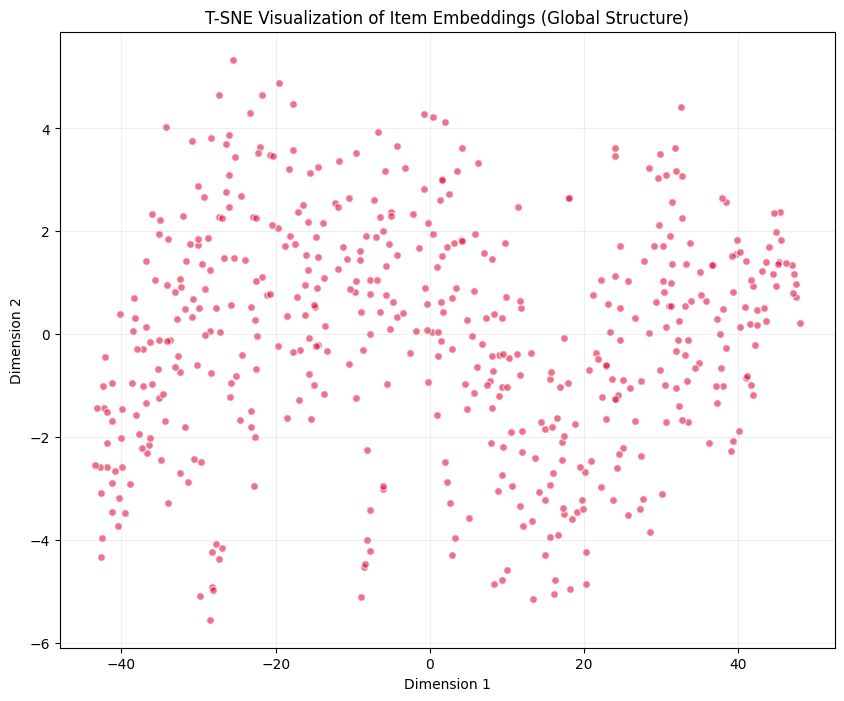

In [23]:
from sklearn.manifold import TSNE

def plot_item_embeddings(model, edge_index, num_items_to_plot=500):
    model.eval()
    with torch.no_grad():
        # 获取经过GCN增强后的物品Embedding
        _, item_embs = model(torch.ones((1, 50), dtype=torch.long).to(device), edge_index)
        # 取前N个热门物品（避开长尾噪声）
        embeddings = item_embs[1:num_items_to_plot+1].cpu().numpy()
        
    tsne = TSNE(n_components=2, random_state=42)
    low_dim_embs = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(low_dim_embs[:, 0], low_dim_embs[:, 1], alpha=0.6, c='crimson', edgecolors='w', s=30)
    plt.title('T-SNE Visualization of Item Embeddings (Global Structure)')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True, alpha=0.2)
    plt.show()

plot_item_embeddings(model, edge_index_ii)

In [ ]:
def plot_score_distribution(model, loader, edge_index, device):
    model.eval()
    pos_scores = []
    neg_scores = []
    
    with torch.no_grad():
        for seq, pos_item, neg_item in loader:
            seq, pos_item, neg_item = seq.to(device), pos_item.to(device), neg_item.to(device)
            user_repr, item_embs = model(seq, edge_index)
            
            p_score = torch.sum(user_repr * item_embs[pos_item], dim=-1)
            n_score = torch.sum(user_repr * item_embs[neg_item].squeeze(1), dim=-1)
            
            pos_scores.extend(p_score.cpu().numpy())
            neg_scores.extend(n_score.cpu().numpy())

    plt.figure(figsize=(10, 6))
    plt.hist(pos_scores, bins=50, alpha=0.5, label='Positive Items', color='g', density=True)
    plt.hist(neg_scores, bins=50, alpha=0.5, label='Negative Items', color='r', density=True)
    plt.title('Score Distribution: Positive vs Negative Samples')
    plt.xlabel('Prediction Score')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

# 使用训练集的一小部分查看
plot_score_distribution(model, train_loader, edge_index_ii, device)

In [ ]:
def plot_performance_by_length(model, dataset, edge_index, device):
    lengths = [torch.count_nonzero(seq).item() for seq, _ in dataset]
    results = [] # 存储 (length, hit)
    
    model.eval()
    with torch.no_grad():
        # 预计算所有物品表示
        dummy_seq = torch.ones((1, 50), dtype=torch.long).to(device)
        _, all_item_embs = model(dummy_seq, edge_index)
        
        for seq, target in dataset:
            seq_len = torch.count_nonzero(seq).item()
            seq_tensor = seq.unsqueeze(0).to(device)
            user_repr, _ = model(seq_tensor, edge_index)
            
            scores = torch.matmul(user_repr, all_item_embs.t())
            _, top_k = torch.topk(scores, 10)
            hit = 1 if target.item() in top_k[0].cpu().numpy() else 0
            results.append((seq_len, hit))

    df_res = pd.DataFrame(results, columns=['length', 'hit'])
    # 按长度分组计算平均HR
    len_acc = df_res.groupby('length')['hit'].mean()

    plt.figure(figsize=(10, 5))
    len_acc.plot(kind='bar', color='skyblue')
    plt.title('HitRate@10 vs. User Sequence Length')
    plt.xlabel('Sequence Length')
    plt.ylabel('Average HitRate')
    plt.xticks(rotation=0)
    plt.show()

# 示例调用
plot_performance_by_length(model, val_dataset, edge_index_ii, device)